In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('mental_health_processed.csv')
target_column = 'On a scale of 1–5, how would you rate your overall mental well-being right now?'
df['well_being_binary'] = np.where(df[target_column] <= 3, 0, 1)
df_x = df.drop(columns=[target_column, 'well_being_binary'])
df_y = df['well_being_binary']

df_x_train, df_x_test, df_y_train, df_y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=50)
class_names = ['Not Good', 'Good']

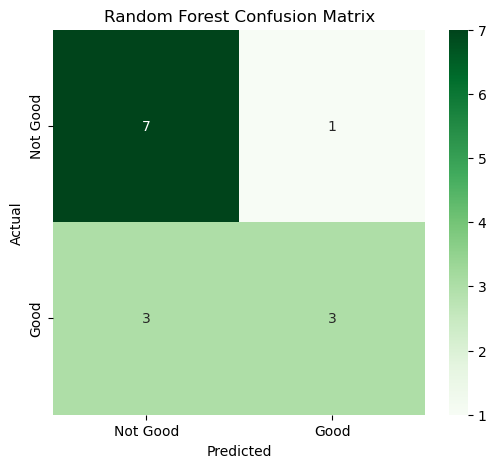

In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(df_x_train, df_y_train)
pred_rf = rf.predict(df_x_test)

#Confusion Matrix
cm_rf = confusion_matrix(df_y_test, pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

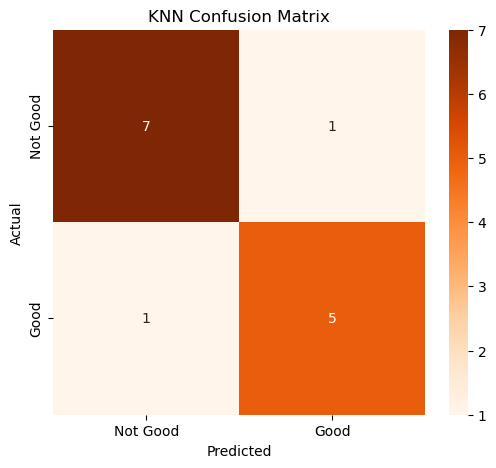

In [12]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(df_x_train, df_y_train)
pred_knn = knn.predict(df_x_test)

#Confusion Matrix
cm_knn = confusion_matrix(df_y_test, pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title('KNN Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

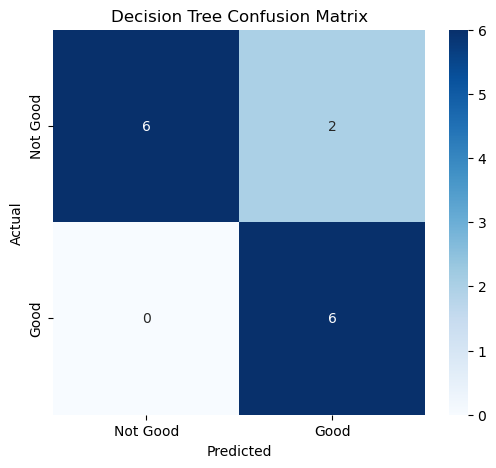

In [14]:
dt = DecisionTreeClassifier(random_state=40)
dt.fit(df_x_train, df_y_train)
pred_dt = dt.predict(df_x_test)

#Confusion Matrix
cm_dt = confusion_matrix(df_y_test, pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()